In [5]:
from langchain.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from pydantic import Field, BaseModel
from pathlib import Path
from dotenv import load_dotenv
from typing import TypedDict, List, Literal, Any
import requests
import json
import os

In [2]:
import google.generativeai as genai

d:\LearnXYZ\learnenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ralxi\AppData\Local\Temp\ipykernel_12632\613638648.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
load_dotenv()

True

In [40]:
r = requests.get(
    "https://openrouter.ai/api/v1/models",
    headers={"Authorization": f"Bearer {os.getenv("OPENAI_API_KEY")}"}
)

for m in r.json()["data"]:
    if m["pricing"]["prompt"] == "0":
        print(m["id"])

stealth/ox-alpha
dots-studio/dots-3-note-preview:free
liquid/lfm-2.5-2.6b:free
nvidia/nemotron-3.5-lightning:free
thinkingmachines/inkling-small:free
poolside/laguna-s-2.1:free
thinkingmachines/inkling:free
poolside/laguna-xs-2.1:free
cohere/north-mini-code:free
z-ai/glm-5.2:free
nvidia/nemotron-3.5-content-safety:free
nvidia/nemotron-3-ultra-550b-a55b:free
minimax/minimax-m3:free
nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
google/gemma-4-26b-a4b-it:free
google/gemma-4-31b-it:free
google/lyria-3-pro-preview
google/lyria-3-clip-preview
minimax/minimax-m2.7:free
nvidia/nemotron-3-super-120b-a12b:free
openrouter/free


In [ ]:
model = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash",
    api_key = os.getenv("GEMINI_API_KEY"),
    temperature = 0
)

model.invoke("Who is the president of India")

In [43]:
modeli = ChatOpenAI(
    model = "openrouter/free",
    openai_api_key = os.environ["OPENAI_API_KEY"],
    openai_api_base = os.environ["OPENAI_API_BASE"]
)

In [44]:
resp = modeli.invoke("Who is th president of india")
print(resp.text)

As of my last update in July 2024, the **President of India is Droupadi Murmu**.

She assumed office on **25 July 2022**, becoming the **15th President of India**. Key points about her presidency:

- She is the **first person belonging to a tribal community** (Santhal) to hold the office.
- She is the **second woman** to serve as President of India (after Pratibha Patil, 2007–2012).
- Her term is for five years, so she is scheduled to serve until **25 July 2027** (unless circumstances change otherwise).

**Note:** The President of India is the **head of state**, while the **Head of Government** is the Prime Minister (currently Narendra Modi, since 2014). The President's role is largely ceremonial and constitutional, with executive power exercised by the Council of Ministers led by the Prime Minister.

If you need information about the Prime Minister or other details, feel free to ask!


In [14]:
class Topic(BaseModel):
    name: str
    difficulty: Literal["High", "Medium", "Low"]
    definition: str
    Links: str
    articles: List

class Subtopic(BaseModel):
    subtopic_name: str
    difficulty: Literal["High", "Medium", "Low"]
    definition: str
    topics: List[Topic]

class MindMap(BaseModel):
    topic_name: str
    definition: str
    sutopics: List[Subtopic]

struct_model = modeli.with_structured_output(MindMap)

In [16]:
resp = struct_model.invoke("generate a learning roadmap of Machine Learning")
print(resp)

KeyboardInterrupt: 

In [51]:
prompt = f"""You are an expert learning-roadmap generator.

Your task is to create a structured learning roadmap for any topic provided by the user.

The roadmap must organize the topic from foundational concepts to advanced concepts and should help a learner understand what they should learn and in what order.

Follow these rules:

1. Identify the major subtopics required to understand the given topic.
2. Arrange the subtopics in a logical learning sequence, generally from foundational concepts to advanced concepts.
3. For every subtopic:
   - Provide a clear subtopic name.
   - Assign a difficulty level: "Low", "Medium", or "High".
   - Give a moderate amount of description about the topic
   - Identify the important concepts/topics that should be learned within that subtopic.
4. For every topic inside a subtopic:
   - Provide a concise and meaningful topic name.
   - Give a moderate amount of description about the topic
   - Assign a difficulty level: "Low", "Medium", or "High".
   - generate a youtube video link for the topic (give only the links for the youtube videos that exists don't try to make up links else write focus on articles)
   - 2-3 articles for the topic
5. Include prerequisite concepts before concepts that depend on them.
6. Do not include unnecessary or highly specialized concepts unless they are important for understanding the topic.
7. The roadmap should be comprehensive enough for a learner to progress from beginner to advanced level.
8. Avoid duplicate topics.
9. Difficulty should represent the relative complexity of learning the concept, not its importance.
10. The number of subtopics and topics should depend on the complexity of the input topic. Do not use a fixed number.
11. Return only the structured output defined by the provided schema. Do not return explanations, Markdown, comments, or additional text.

The input will be a topic that the user wants to learn.

return only in json format

not any other format

Generate the learning roadmap for that topic."""

In [ ]:
sysquery = SystemMessage(content=prompt)
humquery = HumanMessage(content="Machine Learning")
query = [sysquery,humquery]

response = struct_model.invoke(query)
roadmap = response.model_dump()

In [ ]:
print(roadmap)

{'topic_name': 'Machine Learning', 'definition': 'Machine Learning (ML) is a subset of Artificial Intelligence (AI) that enables systems to learn from data, identify patterns, and make decisions with minimal human intervention. It involves developing algorithms that can parse data, learn from it, and then make a prediction or decision.', 'sutopics': [{'subtopic_name': 'Foundational Math & Programming', 'difficulty': 'Low', 'definition': 'This section covers the essential mathematical and programming prerequisites necessary to understand and implement machine learning algorithms effectively. A strong foundation here will make subsequent topics much easier to grasp.', 'topics': [{'name': 'Python Programming Basics', 'difficulty': 'Low', 'definition': 'Learn the fundamentals of Python, including data types, control flow, functions, and basic data structures like lists, dictionaries, and tuples. This is the primary language for most ML development.', 'Links': 'https://www.youtube.com/watch

In [52]:
class SubjectState(TypedDict):
    topic: str
    roadmap: dict[str, Any]

In [53]:
def roadmapnode(state: SubjectState):
    sysquery = SystemMessage(content=prompt)
    humquery = HumanMessage(content=state["topic"])
    query = [sysquery,humquery]

    response = struct_model.invoke(query)
    roadmap = response.model_dump()
    return {"roadmap": roadmap}

def save_roadmap(state: SubjectState):

    path = Path("module.json")
    path.parent.mkdir(parents=True,exist_ok=True)

    if path.exists() and path.stat().st_size > 0:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        data = {}

    data[state["topic"]] = state["roadmap"]

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

    return {}


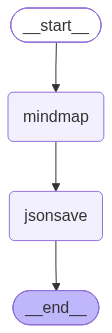

In [54]:
graph = StateGraph(SubjectState)
graph.add_node("mindmap", roadmapnode)
graph.add_node("jsonsave", save_roadmap)
graph.add_edge(START, "mindmap")
graph.add_edge("mindmap", "jsonsave")
graph.add_edge("jsonsave", END)
graph.compile()

In [55]:
workflow = graph.compile()
initial_state = {"topic": "Convolution Nueral Network"}
final_state = workflow.invoke(initial_state)

In [56]:
print(final_state["roadmap"])

{'topic_name': 'Convolutional Neural Networks', 'definition': 'A deep learning architecture specialized for processing grid-like data such as images, using convolutional operations to extract hierarchical features.', 'sutopics': [{'subtopic_name': 'Foundations of Neural Networks', 'difficulty': 'Low', 'definition': 'Understanding basic neural network concepts, including perceptrons, activation functions, and gradient descent.', 'topics': [{'name': 'Perceptrons and Feedforward Networks', 'difficulty': 'Low', 'definition': 'Introduction to single-layer and multi-layer perceptrons, linear algebra basics for neural networks.', 'Links': 'https://www.youtube.com/watch?v=14qRqQjC5qQ', 'articles': ['https://www.geeksforgeeks.org/perceptron neural-network-in-python/', 'https://machinelearningmastery.com/build-your-first-neural-network-from-scratch/']}, {'name': 'Activation Functions', 'difficulty': 'Low', 'definition': 'Sigmoid, tanh, ReLU, and their role in introducing non-linearity to neural 